<img src="data_sig_logo.jpg" width="450">

# Low-rank and sparse structured approximations for large linear maps

This notebook uses ideas and methods from the following papers:
> Nathan Halko, Per-Gunnar Martinsson, Joel A. Tropp, (2011). "Finding structure with randomness: Probabilistic algorithms for constructing approximate matrix decompositions", arXiv preprint arXiv:__[0909.4061](https://arxiv.org/abs/0909.4061)__

> David P. Woodruff, (2014). "Sketching as a Tool for Numerical Linear Algebra", arXiv preprint arXiv:__[1411.4357](https://arxiv.org/abs/1411.4357)__

The theoretical foundations for this notebook draw on the following key works:
>Carl Eckart, Gale Young (1936). "The approximation of one matrix by another of lower rank", Psychometrika, 1(3), 211–218.

>Vladimir A. Marchenko, Leonid A. Pastur (1967). "Distribution of eigenvalues in certain sets of random matrices", Matematicheskii Sbornik, 114(4), 507–536.

## Motivation

Modern machine learning models rely on many large linear maps, usually implemented as matrix-vector or matrix-matrix multiplications. These operations often dominate memory use and computational cost, especially in neural networks with large hidden layers, attention projections, or embedding maps. A classical way to simplify such operators is to replace a large matrix by a low-rank approximation. Randomised numerical linear algebra extends these ideas by using sampling and sketching to obtain cheaper approximations for large matrices.


We begin by setting up the coding environment.

## Requirements

To run this notebook, the dependencies listed in [`requirements.txt`](requirements.txt) are necessary. 

## Environment Setup

It is recommended to use a virtual environment when running this notebook. After creating and activating your environment, install the required packages using:

```pip install -r requirements.txt```

## Import Packages

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
import torch
from torchvision import datasets, transforms
from scipy.integrate import quad
from scipy.optimize import root_scalar

## Downloading Datasets

In [ ]:
mnist = datasets.MNIST( root="./data", train=True, download=True, transform=transforms.ToTensor())

cifar = datasets.CIFAR10(root="./data", train=True, download=True, transform=transforms.Compose([transforms.Grayscale(), transforms.ToTensor()]))

## Low‑Rank Methods — Numerical Experiments

We implement and compare randomised low‑rank approximation algorithms against the optimal truncated SVD under unitarily invariant norms (e.g. Frobenius). All experiments are performed on synthetic Gaussian matrices. Below are the functions we will need to compare our methods.

### Optimal truncated SVD implementation:

In [ ]:
# unique iff S[r-1]>S[r], otherwise any of the rth largest singular values chosen (depending on list S)

def svd_optimal(A, r):
    """
    Computes an optimal solution for SVD rank-r truncation

    Parameters:
    A (nested list of depth 2): The matrix to be approximated
    r (int): The rank of the approximation

    Returns:
    A_r (numpy array): The rank-r approximation matrix, shape (m, n)
    U_r (numpy array): The first r left singular vectors of A, shape (m, r)
    S_r (nupy array): The diagonal matrix of the first r singular values, shape (r, n)
    Vt_r (numpy array): The first r right singular vectors of A, transposed, shape (r, n)
    """

    A=np.array(A)
    r = min(r, min(A.shape))
    
    U,S,Vt = np.linalg.svd(A, full_matrices=False)

    S_r = np.diag(S[:r])
    U_r = U[ : , :r]
    Vt_r = Vt[ :r, : ]

    A_r = U_r @ S_r @ Vt_r

    return A_r, U_r, S_r, Vt_r

### Randomised SVD implementation:

In [ ]:
# Original matrix A has dim mxn
# Rank-2k approx.


# Stage-A of prototype for randomised SVD 
def stage_A(A, k, q):

    test_matrix = np.random.normal(0, 1, (A.shape[1], 2*k))

    Y = A @ test_matrix  

    # Orthonormalisation step between each multiplication of A and A* 
    Q, _ = np.linalg.qr(Y, mode='reduced')
    
    for _ in range(q):
       
        Q = A.conj().T @ Q   
        Q, _ = np.linalg.qr(Q, mode='reduced')
        
        Q = A @ Q  
        Q, _ = np.linalg.qr(Q, mode='reduced')

    return Q


# Stage-B of prototype for randomised SVD
def stage_B(A, k, q):

    Q = stage_A(A, k, q)

    B = Q.conj().T @ A
    U_B, S, V_t = np.linalg.svd(B, full_matrices=False)
    S = np.diag(S)

    U = Q @ U_B

    return U, S, V_t


# Final rank-r factorisation using randomised SVD (r must be integer multiple of 2)
def svd_random(A, r, q):

    if r % 2 != 0:
        return None

    U, S, V_t = stage_B(A, r//2, q)
    A_randsvd = U @ S @ V_t

    return A_randsvd, U, S, V_t

### Required functions for relevant plots:

In [ ]:
VARIANCE_FORMULAS = {
    np.random.normal: lambda loc, scale: scale**2,
    np.random.uniform: lambda low, high: (high - low)**2 / 12,
    np.random.poisson: lambda lam: lam,
    np.random.binomial: lambda n, p: n * p * (1 - p),
    np.random.gamma: lambda shape, scale: shape * scale**2,
    np.random.exponential: lambda scale: scale**2,
}

def get_variance(dist, **dist_kwargs):
    return VARIANCE_FORMULAS[dist](**dist_kwargs)

###########################################################################################################################################################################


def svd_error(A, norm_type, svd_type, svd_type_kwargs):

    """
    Computes Frobenius distance of rank-r approximation and the original matrix

    Parameters:
    A (nested list of depth 2): The original matrix 
    r (int): The rank of the approximation
    norm_type: Norm to be used. eg: 'fro' (Frobenius), 2 (Spectral)
    svd_type: SVD approx to be used. eg: 'svd_optimal' , 'svd_random'
    svd_type_kwargs: Dictionary of the required parameters for the chosen svd_type 

    Returns:
    error (float): The error in the 'norm_type' norm
    """

    A_r, U_r, S_r, Vt_r = svd_type(A, **svd_type_kwargs)
    error = np.linalg.norm(A_r - A, ord=norm_type)

    return error




def random_matrix(shape, dist, dist_kwargs):
    """
    Generates a matrix with entries drawn iid from 'dist' and with size 'shape'

    Parameters:
    shape (integer tuple): The size of the desired matrix, of the form (n, m)
    dist: The desired distribution - X - of entries, of the form np.random.X
    dist_kwargs: Dictionary of the required parameters for the chosen distribution

    Returns:
    A (2D numpy array): The required matrix with entries drawn iid from 'dist' and with size 'shape'
    """
    A = dist(size=shape, **dist_kwargs)
    return A



# using normal distribution around optimal solution for perturbated matrices (any rank)
# scaled variance so that perturbations are reasonable, S_r[0,0] is largest singular value
def svd_free_rank_perturbation_plot(A, r, num_perturbed, norm_type, svd_type, svd_type_kwargs):

    """
    Generates scatter plot of perturbed matrices (with any rank) distance from A against distance from optimal rank-r approximation

    Parameters:
    A (nested list of depth 2): The original matrix 
    num_perturbed: The number of perturbated matrices to be plotted
    norm_type: Norm to be used. eg: 'fro' (Frobenius), 2 (Spectral)
    svd_type: SVD approx to be used. eg: 'svd_optimal' , 'svd_random'
    svd_type_kwargs: The required parameters for the chosen svd_type

    Returns:
    A scatter plot (shows how rank-r approx. is not necessarily best approx. amongst all ranks)
    """

    A_r, U_r, S_r, Vt_r = svd_type(A, r, **svd_type_kwargs)

# list of perturbed matrices. vectored using 3D numpy array instead of loop
    A_perturbed = A_r + np.random.normal(0, 0.05*S_r[0,0], (num_perturbed, A_r.shape[0], A_r.shape[1]))

# x-axis: distance (Frobenius) of perturbed matrix from optimal rank-r truncation
    distance_approx = np.linalg.norm(A_perturbed - A_r, ord=norm_type, axis=(1,2))
    distance_true = np.linalg.norm(A_perturbed - A, ord=norm_type, axis=(1,2))

    plt.scatter(distance_approx, distance_true, color='blue', s=20)
    plt.scatter([0], svd_error(A, r, norm_type, svd_type, svd_type_kwargs), color='red')
    plt.xlabel(f"Distance from rank-{r} approx.")
    plt.ylabel("Distance from true matrix")
    plt.title("Perturbation Scatter")
    plt.show()



def svd_error(A, r, norm_type, svd_type, svd_type_kwargs):

    """
    Computes Frobenius distance of rank-r approximation and the original matrix

    Parameters:
    A (nested list of depth 2): The original matrix 
    r: Rank of SVD approx.
    norm_type: Norm to be used. eg: 'fro' (Frobenius), 2 (Spectral)
    svd_type: SVD approx. to be used
    svd_type_kwargs: Dictionary of relevant parameters
    
    Returns:
    error (float): The error in the Frobenius norm
    """

    if svd_type(A, r, **svd_type_kwargs) is None:
        return np.nan

    A_r, U_r, S_r, Vt_r = svd_type(A, r, **svd_type_kwargs)

    error = np.linalg.norm(A_r - A, ord=norm_type)

    return error



def error_ranksize_table(r_max, n_max, norm_type, svd_type, svd_type_kwargs, dist, dist_kwargs):

    """
    Generates table showing error between original matrix of size (nxn) and optimal rank-r approximation 

    Parameters:
    r_max (int): The highest rank approximation desired
    n_max (int): The greatest number of rows for the matrix being approximated
    norm_type: Norm to be used. eg: 'fro' (Frobenius), 2 (Spectral)
    dist: The desired distribution - X - of entries, of the form np.random.X
    **dist_kwargs: The required parameters for the chosen distribution

    Returns:
    Table showing the error for each rank r and size nxn respectively 
    """
    rank_list = np.arange(1, r_max+1, 1)
    size_list = [f"{i}x{i}" for i in range(1, n_max+1, 1)]
    matrix_list = [dist(size=(i, i), **dist_kwargs) for i in range(1, n_max+1)]

    rankr_error_table = np.array([[svd_error(matrix_list[j], rank_list[i], norm_type, svd_type, svd_type_kwargs) for j in range(n_max)] for i in range(r_max)])

    table = pd.DataFrame(rankr_error_table, index=rank_list, columns=size_list)
    print(table)

    plt.figure(figsize=(12, 6))
    plt.imshow(table, cmap="Reds", aspect="auto") 
    plt.colorbar(label="Error")

    plt.xticks(np.arange(len(table.columns)), table.columns, rotation=45)
    plt.yticks(np.arange(len(table.index)), table.index)

    plt.xlabel("matrix size")
    plt.ylabel("rank")
    plt.title("Rank-r approximation error")
    plt.show()



def error_ranksize_plot(r, n_max, norm_type, svd_type, svd_type_kwargs, dist, dist_kwargs):

    """
    Generates scatter showing error of the rank-r approx. against the size of the matrix (to see behaviour as n grows, whilst r stays the same)

    Parameters:
    r (int): The rank of approximation desired (fixed)
    n_max (int): The greatest number of rows for the matrix being approximated
    norm_type: Norm to be used. eg: 'fro' (Frobenius), 2 (Spectral)
    dist: The desired distribution - X - of entries, of the form np.random.X
    **dist_kwargs: The required parameters for the chosen distribution

    Returns:
    Scatter plot showing how error changes as size changes, for a fixed rank
    """

    matrix_list = [dist(size=(i, i), **dist_kwargs) for i in range(1, n_max+1)]
    rankr_error_list = np.array([svd_error(matrix_list[j], r, norm_type, svd_type, svd_type_kwargs) for j in range(n_max)])
    
    index_list = np.arange(1, n_max+1, 1)

    plt.scatter(index_list, rankr_error_list, color='red', s=20)
    plt.xlabel("#rows of the square matrix")
    plt.ylabel("Error in approx.")
    plt.title("Error against size (fixed rank)")
    plt.show()



# same rank perturbation
def svd_fixed_rank_perturbation_plot(A, r, norm_type, num_perturbed, svd_type, svd_type_kwargs, rotation=False):

    """
    Generates scatter plot of perturbed matrices (with fixed rank r) distance from A against distance from optimal rank-r approximation

    Parameters:
    A (nested list of depth 2): The original matrix 
    r (int): The rank of the approximation
    num_perturbed: The number of perturbated rank-r matrices to be plotted

    Returns:
    A scatter plot that shows optimality of A_r for that fixed rank r
    """

    A_r, U_r, S_r, Vt_r = svd_type(A, r, **svd_type_kwargs)

    S_r = list(np.diag(S_r))

    try:
        k = S_r.index(0) 
    except ValueError:
        k = r

    S_r = np.array(S_r)

    pert_list = np.zeros((num_perturbed, r))
    pert_list[:, :k] = np.random.normal(0, 0.05*S_r[-1], (num_perturbed, k))

    sv_perturbed = S_r + pert_list
    S_r_pert_list = np.array([np.diag(i) for i in sv_perturbed])

    A_r_pert_list = U_r @ S_r_pert_list @ Vt_r

    if rotation: 

        Q_1, R_1 = np.linalg.qr(np.random.normal(0, 10**(-20), (A.shape[0], A.shape[0])))
        if np.linalg.det(Q_1) < 0:
            Q_1[:, 0] = -Q_1[:, 0]

        Q_2, R_2 = np.linalg.qr(np.random.normal(0, 10**(-20), (A.shape[1], A.shape[1])))
        if np.linalg.det(Q_2) < 0:
            Q_2[:, 0] = -Q_2[:, 0]
        
        A_r_pert_list = Q_1 @ A_r_pert_list @ Q_2

        distance_approx = np.linalg.norm(A_r_pert_list - A_r, ord=norm_type, axis=(1,2))
        distance_true = np.linalg.norm(A_r_pert_list - A, ord=norm_type, axis=(1,2))

        plt.scatter(distance_approx, distance_true, color='blue', s=20)
        plt.scatter([0], svd_error(A, r, norm_type, svd_type, svd_type_kwargs), color='red')
        plt.xlabel(f"Distance from rank-{r} approx.")
        plt.ylabel("Distance from true matrix")
        plt.title("Rank-r Perturbation Scatter")
        plt.show()

    else:

        distance_approx = np.linalg.norm(A_r_pert_list - A_r, 'fro', axis=(1,2))
        distance_true = np.linalg.norm(A_r_pert_list - A, 'fro', axis=(1,2))

        plt.scatter(distance_approx, distance_true, color='blue', s=20)
        plt.scatter([0], svd_error(A, r, norm_type, svd_type, svd_type_kwargs), color='red')
        plt.xlabel(f"Distance from rank-{r} approx.")
        plt.ylabel("Distance from true matrix")
        plt.title("Rank-r Perturbation Scatter")
        plt.show()


def error_ranksize_semilogy(r_max, n_max, norm_type, svd_type, svd_type_kwargs, dist, dist_kwargs):

    rank_list = np.arange(2, r_max + 1, 2)

    size_list = [f"{i}x{i}" for i in range(1, n_max + 1)]

    matrix_list = [
        dist(size=(i, i), **dist_kwargs)
        for i in range(1, n_max + 1)
    ]

    rankr_error_table = np.array([
        [
            svd_error(
                matrix_list[j],
                rank_list[i],
                norm_type,
                svd_type,
                svd_type_kwargs
            )
            for j in range(n_max)
        ]
        for i in range(len(rank_list))
    ])

    plt.figure(figsize=(12, 6))

    for j in range(9, n_max, 10):
        plt.semilogy(
            rank_list,
            rankr_error_table[:, j],
            label=size_list[j]
        )

    plt.xlabel("rank $r$")
    plt.ylabel("error")
    plt.title("Rank-$r$ approximation error")
    plt.legend(title="matrix size")
    plt.grid(True, which="both", alpha=0.3)

    plt.show()

A = random_matrix((5,6), np.random.normal, {'loc':0, 'scale':1})

## Example plots for: Optimal truncated SVD approx.

#### Experiment A

Comparing the given approximation against other matrices which satisfy the same restraints.
We see that for any fixed rank matrix, this approximation gives the solution with smallest error (red dot)

Rank-2 approximation 

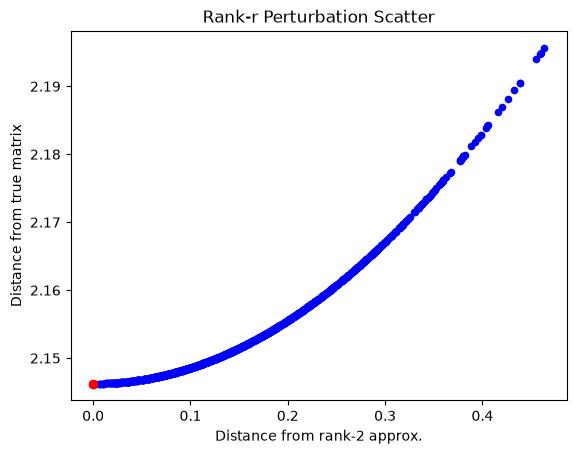

In [ ]:
svd_fixed_rank_perturbation_plot(A, 2, 'fro', 1500, svd_optimal, {}, ) 

Rank-4 approximation 

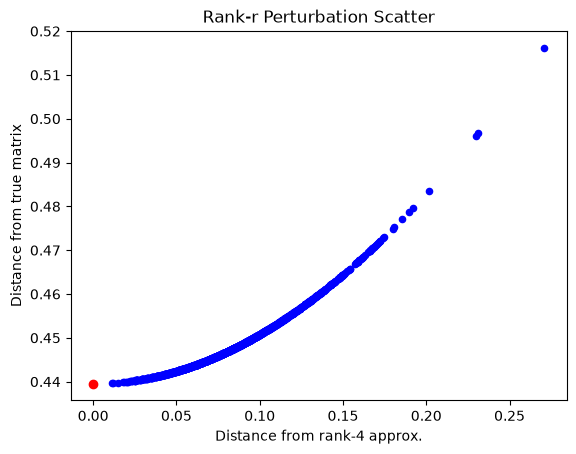

In [ ]:
svd_fixed_rank_perturbation_plot(A, 4, 'fro', 1500, svd_optimal, {}, ) 

#### Experiment B

Comparing the error between approximation and true matrix at different ranks.

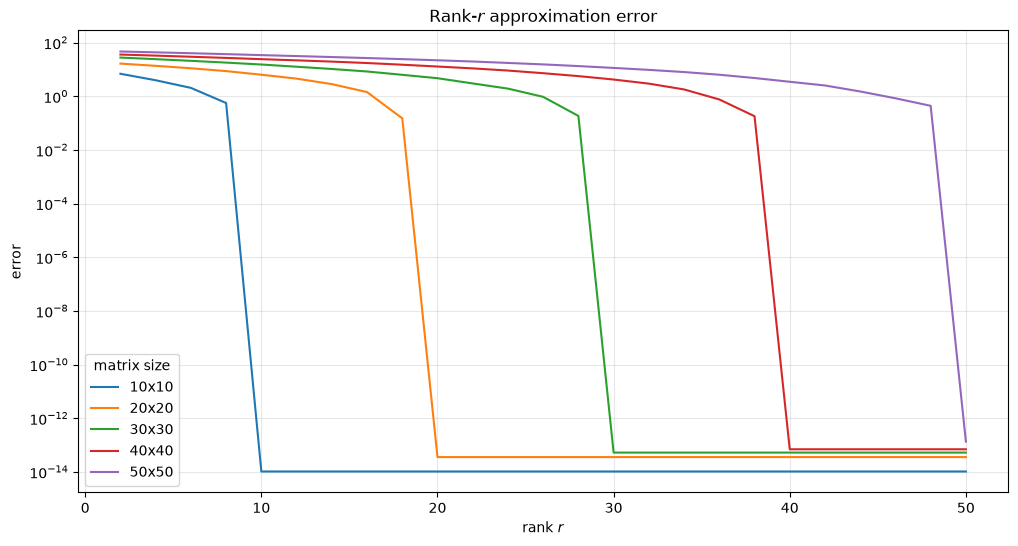

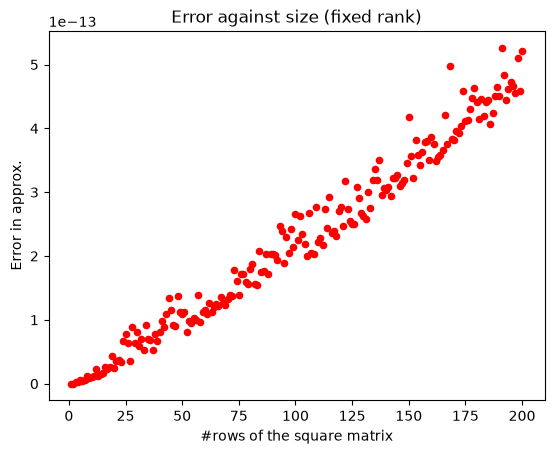

In [ ]:
error_ranksize_semilogy(50, 50, 'fro', svd_optimal, {}, np.random.normal, {'loc':0, 'scale':1}) 

error_ranksize_plot(200, 200, 'fro', svd_optimal, {}, np.random.normal, {'loc':0, 'scale':1})

## Example plots for: Randomised SVD approx. 

#### Experiment A

Comparing the given approximation against other matrices which satisfy the same restraints. 
We see that increasing `q` reduces the error (distance from true matrix) since the larger singular values start to dominate when raised to a higher power. Additionally, the approximation is not necessarily the best under the given constraints, owing to randomness.

Rank-2 approximation (q=0, q=2)

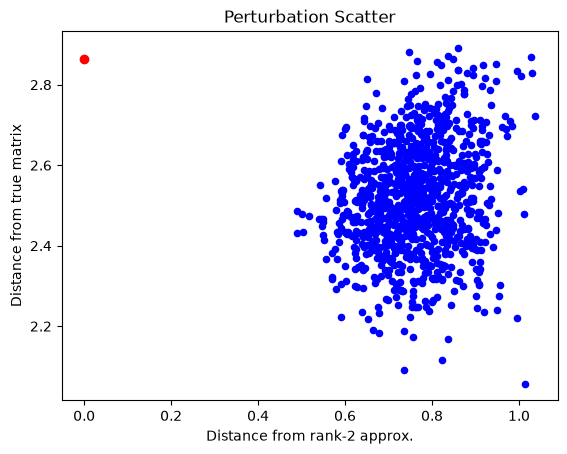

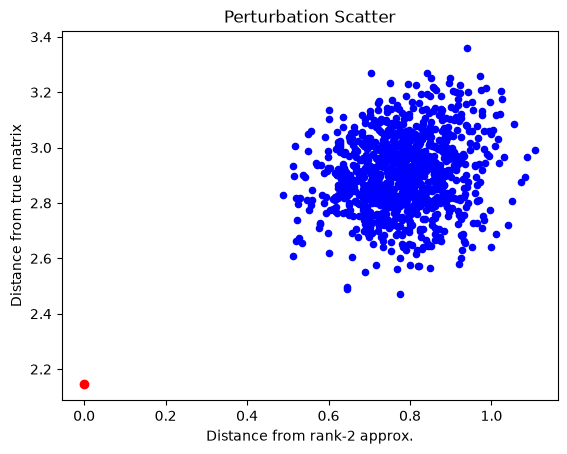

In [ ]:
svd_free_rank_perturbation_plot(A, 2, 1000, 'fro', svd_random, {'q':0})
svd_free_rank_perturbation_plot(A, 2, 1000, 'fro', svd_random, {'q':2})

Rank-4 approximation (q=0, q=2)

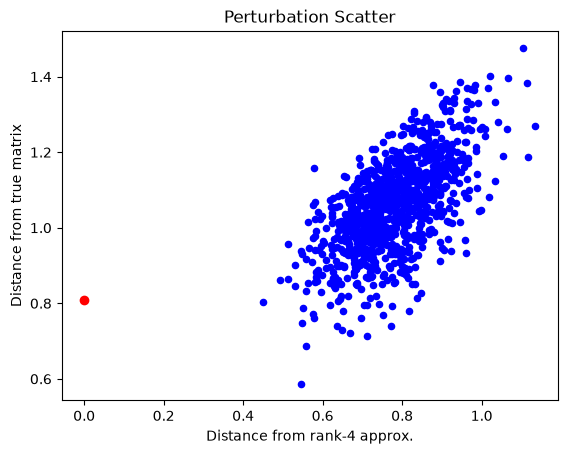

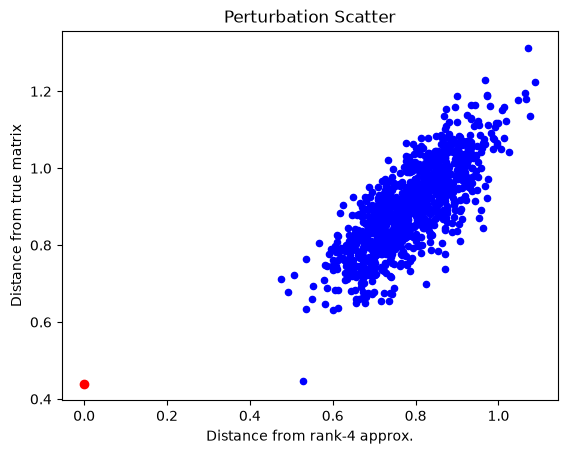

In [ ]:
svd_free_rank_perturbation_plot(A, 4, 1000, 'fro', svd_random, {'q':0})
svd_free_rank_perturbation_plot(A, 4, 1000, 'fro', svd_random, {'q':2})

#### Experiment B

Comparing the error between approximation and true matrix at different ranks.

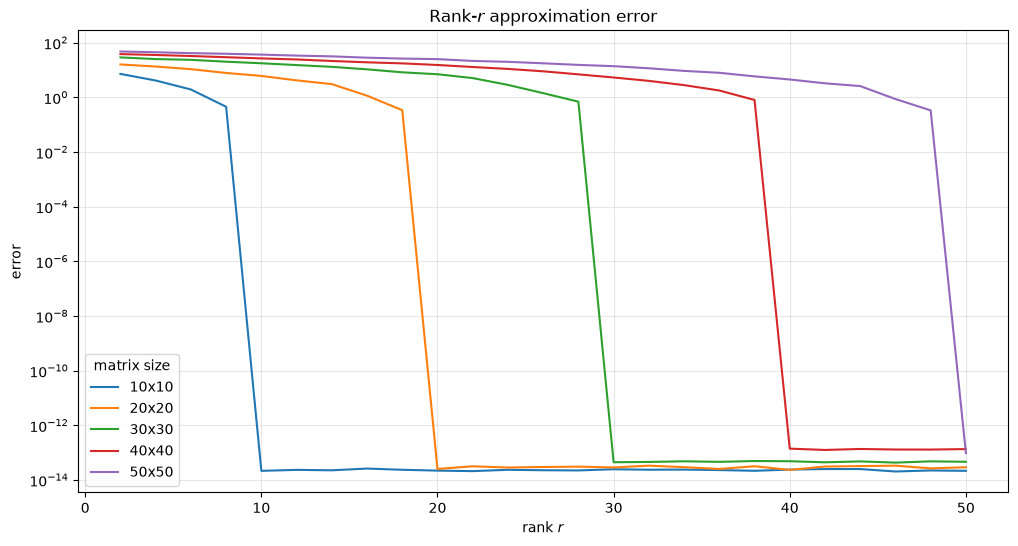

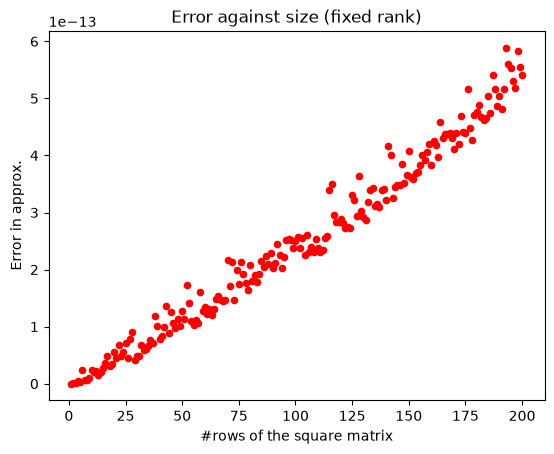

In [ ]:
error_ranksize_semilogy(50, 50, 'fro', svd_random, {'q':1}, np.random.normal, {'loc':0, 'scale':1}) 

error_ranksize_plot(200, 200, 'fro', svd_random, {'q':1}, np.random.normal, {'loc':0, 'scale':1})

## Marchenko-Pastur Distribution 

We use the Marchenko–Pastur distribution to characterise the singular value spectrum of large Gaussian matrices. It captures the asymptotic spectral decay and describes how the bulk of the singular values is distributed in high-dimensional regimes, providing a clear baseline for interpreting empirical data when comparing approximation methods on synthetic Gaussian matrices.

### Empirical Verification

In [ ]:
# Marchenko-Pastur Law investigation (particular to Frobenius norm and svd_optimal)

def mp_pdf(mu, lam, dist, **dist_kwargs):

    sigma2 = get_variance(dist, **dist_kwargs)

    mu_min = sigma2 * (1 - np.sqrt(lam))**2
    mu_max = sigma2 * (1 + np.sqrt(lam))**2

    if mu < mu_min or mu > mu_max:
        return 0

    numerator = np.sqrt((mu - mu_min) * (mu_max - mu))
    denominator = 2 * np.pi * sigma2 * lam * mu
    pdf = numerator / denominator

    return pdf



# To find mu_r numerically:
def find_mu_r(r, m, lam, dist, **dist_kwargs):

    sigma2 = get_variance(dist, **dist_kwargs)

    mu_min = sigma2 * (1 - np.sqrt(lam))**2
    mu_max = sigma2 * (1 + np.sqrt(lam))**2
    
    if r == 0:
        return mu_max  
    if r >= m:
        return mu_min

    def prob_above(upper_limit):
        return quad(lambda mu: mp_pdf(mu, lam, dist, **dist_kwargs), upper_limit, mu_max)[0]
    
    # Want prob_above(mu_r) = r/m
    target = r / m
    # Tolerance
    epsilon = 1e-6

    result = root_scalar(
        lambda mu: prob_above(mu) - target,
        bracket=[mu_min + epsilon, mu_max - epsilon],
        method='bisect'
    )
    
    return result.root



def expected_squared_error_theoretical(n, m, r, dist, **dist_kwargs):

    sigma2 = get_variance(dist, **dist_kwargs)
    lam = m / n
    
    if r == 0:
        return n * m * sigma2
    if r >= m:
        return 0.0
    
    mu_r = find_mu_r(r, m, lam, dist, **dist_kwargs)
    mu_min = sigma2 * (1 - np.sqrt(lam))**2
    
    integrand = lambda mu: mu * mp_pdf(mu, lam, dist, **dist_kwargs)
    integral, _ = quad(integrand, mu_min, mu_r)

    expected_error = (1 / lam) * integral

    return expected_error



def expected_squared_error_empirical_verification(n, m, r, k, dist, prnt=False, **dist_kwargs):

    matrix_list = dist(size=(k, n, m), **dist_kwargs)
    error_list = np.array([svd_error(A, r, 'fro', svd_optimal, {})**2 for A in matrix_list])

    mean_error = (1 / m) * np.mean(error_list)

    expected_error = expected_squared_error_theoretical(n, m, r, dist, **dist_kwargs)

    abs_error_diff = abs(expected_error - mean_error)

    if prnt:
    
        print(f'expected square error = {expected_error}')
        print(f'mean of squared error list = {mean_error}')
        print(f'absolute difference of errors = {abs_error_diff}') 

    return mean_error



def expected_squared_error_empirical_verification_plot(n, m, r, trials_x100, dist, **dist_kwargs):

    x_list = np.arange(100, 100*(trials_x100 + 1), 100)
    y_list = np.array([expected_squared_error_empirical_verification(n, m, r, i, dist, **dist_kwargs) for i in x_list])

    plt.scatter(x_list, y_list)
    plt.xlabel("Number of trials")
    plt.ylabel("Error")
    plt.title("Empirical squared error vs. number of trials")
    plt.show()



def svd_singularvalues_gaussianmatrix(n, m, k):

    """
    Creates different plots showing information about singular values of Gaussian matrices

    Parameters:
    n (int): #rows of matrices
    m (int): #columns of matrices
    k (int): Total number of matrices to be used (sample size)

    Returns:
    Histogram, Boxplot to show dist. of singular values. Histogram of smallest and largest singular values to see behaviour at either end.
    """

    gaussian_list = np.random.normal(0, 1, (k, n, m))
    U,S,Vt = np.linalg.svd(gaussian_list, full_matrices=False)

    singularvalues_list = np.array(S).flatten()

# histogram of singular values:
    plt.hist(singularvalues_list, bins=100, density=True)
    plt.xlabel("Singular value")
    plt.ylabel("Density")
    plt.show()

# histogram of smallest and largest singular values
    largest_sv  = S[:, 0]
    smallest_sv = S[:, -1]

    S = np.array(S).flatten()

    plt.hist(largest_sv, bins=50, density=True, alpha=0.6, label="largest")
    plt.hist(smallest_sv, bins=50, density=True, alpha=0.6, label="smallest")
    plt.legend()
    plt.xlabel("Singular value")
    plt.ylabel("Density")
    plt.show()


#### Theoretical expected squared error (from Marchenko-Pastur distribution):

In [ ]:
print(f'rank 0 expected suared error is: {expected_squared_error_theoretical(5,4, 0, np.random.normal, loc=0, scale=1)}')
print(f'rank 1 expected suared error is: {expected_squared_error_theoretical(5,4, 1, np.random.normal, loc=0, scale=1)}')
print(f'rank 2 expected suared error is: {expected_squared_error_theoretical(5,4, 2, np.random.normal, loc=0, scale=1)}')
print(f'rank 3 expected suared error is: {expected_squared_error_theoretical(5,4, 3, np.random.normal, loc=0, scale=1)}')
print(f'rank 4 expected suared error is: {expected_squared_error_theoretical(5,4, 4, np.random.normal, loc=0, scale=1)}')

rank 0 expected suared error is: 20
rank 1 expected suared error is: 0.5243467490689578
rank 2 expected suared error is: 0.1774276713449541
rank 3 expected suared error is: 0.03396417352322654
rank 4 expected suared error is: 0.0


#### Computed squared error

Below we see that averaging over several trials brings us close to the theoretical expected squared error

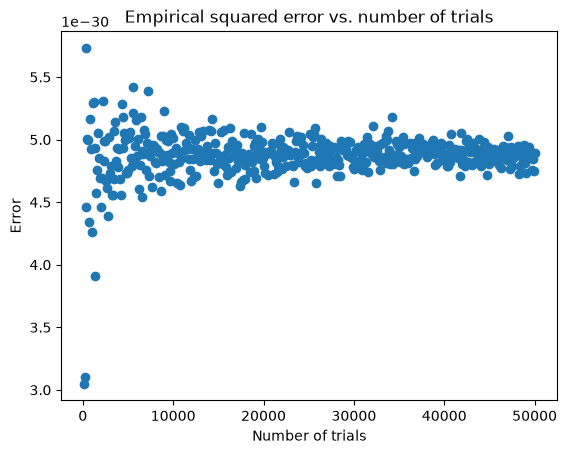

In [ ]:
expected_squared_error_empirical_verification_plot(5, 4, 4, 500, np.random.normal, loc=0, scale=1)

### Spectrum of Singular Values

The Marchenko-Pastur distribution allows to obtain the asymptotic distribution of the singular values of a square Guassian matrix. We plot the density of singular values for many Gaussian matrices to observe this.

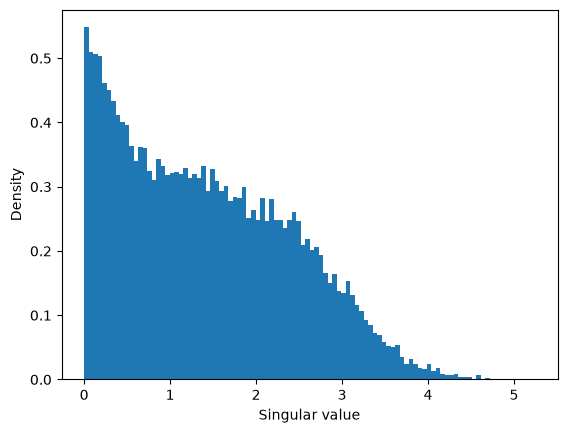

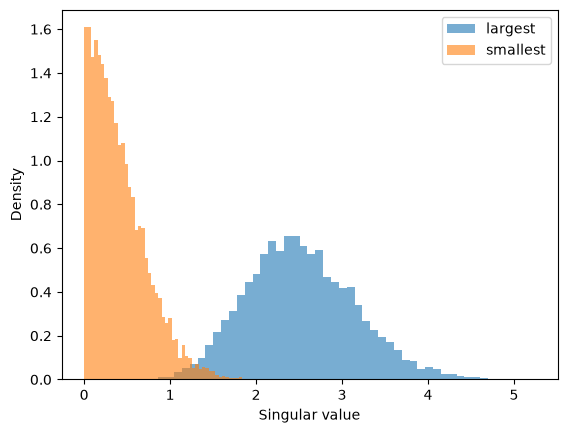

In [ ]:
svd_singularvalues_gaussianmatrix(3, 3, 10000)

## Visual Comparison:

To provide an intuitive visual comparison between the optimal and randomized SVD methods, we apply both techniques to images drawn from the MNIST and CIFAR datasets. This allows us to assess how each approach captures the dominant structure of the data.

In [ ]:
###########################################################################################################################################################################
   
# MNIST dataset (application)

def entry_mnist(i):

    image, label = mnist[i]
    A = image.squeeze().numpy()

    return A, label



# CIFAR-10 dataset (application)

def entry_cifar(i):

    image, label = cifar[i]
    A = image.squeeze().numpy()

    return A, label


###########################################################################################################################################################################


def image_comparison(A, r, svd_type, svd_type_kwargs):

    """
    Produces side-by-side image of original and approx.

    Parameters:
    A (matrix): The matrix representative of the image
    r (int): The rank of the approximation
    svd_type: SVD approx. method to be used. eg: svd_optimal, svd_random
    svd_type_kwargs:
    """

    A_r, U_r, S_r, Vt_r = svd_type(A, r, **svd_type_kwargs)
    

    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.imshow(A, cmap="gray")
    plt.title(f"Original")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(A_r, cmap="gray")
    plt.title(f"Rank-{r} approx.")
    plt.axis("off")

    plt.show()



def error_runtime_comparison(A, r, num_iter, norm_type, svd_type1, svd_type1_kwargs, svd_type2, svd_type2_kwargs):

    error1_list = np.empty(num_iter)
    error2_list = np.empty(num_iter)
    runtime1_list = np.empty(num_iter)
    runtime2_list = np.empty(num_iter)

    for k in range(num_iter):
        
        start = time.perf_counter()
        result1 = svd_type1(A, r, **svd_type1_kwargs)
        end = time.perf_counter()
        runtime1_list[k] = end - start

        if result1 is None:
            return np.nan, np.nan, np.nan, np.nan
        
        A_r1, U1, S1, Vt1 = result1

        
        start = time.perf_counter()
        result2 = svd_type2(A, r, **svd_type2_kwargs)
        end = time.perf_counter()
        runtime2_list[k] = end - start

        if result2 is None:
            return np.nan, np.nan, np.nan, np.nan
        
        A_r2, U2, S2, Vt2 = result2


        error1_list[k] = np.linalg.norm(A_r1 - A, ord=norm_type)
        error2_list[k] = np.linalg.norm(A_r2 - A, ord=norm_type)

    error1 = error1_list.mean()
    error2 = error2_list.mean()
    runtime1 = runtime1_list.mean()
    runtime2 = runtime2_list.mean()

    return error1, error2, runtime1, runtime2



def error_runtime_comparison_plot(A, r_max, num_iter, norm_type, svd_type1, svd_type1_kwargs, svd_type2, svd_type2_kwargs):

    error1_list = np.empty(r_max)
    error2_list = np.empty(r_max)
    runtime1_list = np.empty(r_max)
    runtime2_list = np.empty(r_max)

    for k in range(r_max):
        
        error1, error2, runtime1, runtime2 = error_runtime_comparison(A, k, num_iter, norm_type, svd_type1, svd_type1_kwargs, svd_type2, svd_type2_kwargs)

        error1_list[k] = error1
        error2_list[k] = error2
        runtime1_list[k] = runtime1
        runtime2_list[k] = runtime2

    plt.plot(runtime1_list, error1_list, 'o-', label="svd_optimal")
    plt.plot(runtime2_list, error2_list, 's-', label="svd_random")
    plt.title(f"error against runtime for each rank up to {r_max}")
    plt.xlabel("Runtime (s)")
    plt.ylabel("Error")
    plt.legend()
    plt.show()



def tiled_matrix(rows, cols, entry_type, start):

    images = []
    k = start

    for i in range(rows):
        row = []
        for j in range(cols):
            A, label = entry_type(k)
            row.append(A)
            k = k + 1
        images.append(np.hstack(row))

    A = np.vstack(images)

    return A


### Comparison when q=0

Visually we see that the first approximation (optimal truncation) is closer to the original image than the second approximation (randomised). This is reflected by their respective Frobenius distances from the matrix representation of the original MNIST image.

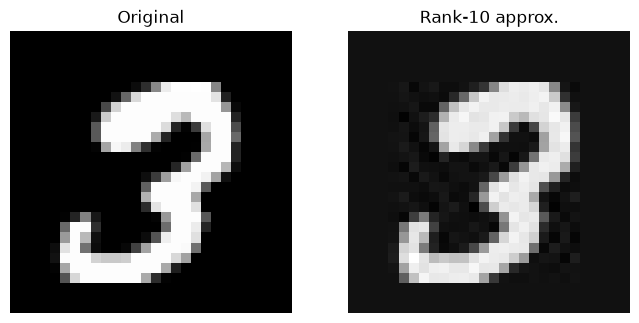

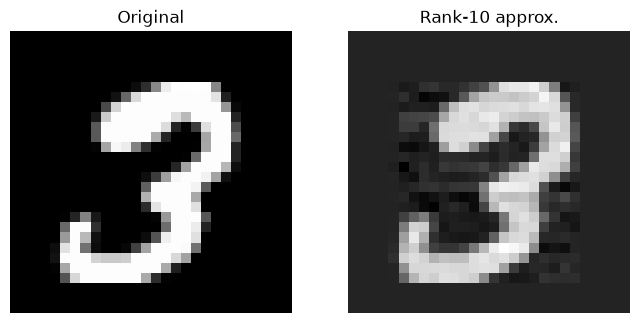

Avg. distance from original matrix: method1 = 0.5788878202438354, method2 = 1.3143628302794692


In [ ]:
A, label = entry_mnist(12345)
image_comparison(A, 10, svd_optimal, {})
image_comparison(A, 10, svd_random, {'q':0})

distance1, distance2, runtime1, runtime2 = error_runtime_comparison(A, 10, 1000, 'fro', svd_optimal, {}, svd_random, {'q':0})
print(f'Avg. distance from original matrix: method1 = {distance1}, method2 = {distance2}')

## Runtime Comparison Plots

To compare the methods, we evaluate and plot their runtimes at each rank using sample images from the dataset, giving a visual sense of how their computational costs differ. In particular, we observe that the randomised scheme achieves substantially lower runtimes for low‑rank approximations and scales favourably as matrix dimensions increase - due to its complexity.

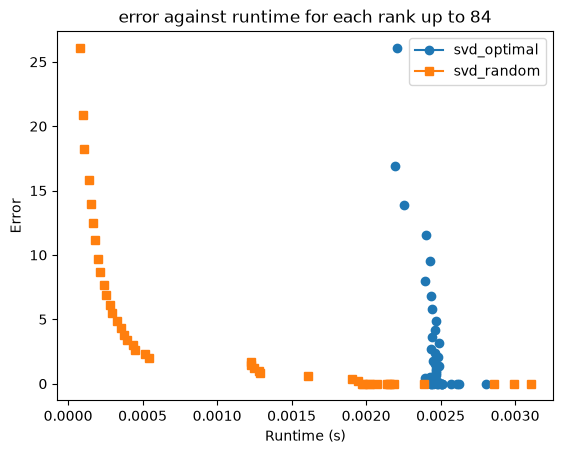

In [ ]:
A = tiled_matrix(3, 3, entry_mnist, 2) #84x84 matrix
error_runtime_comparison_plot(A, 84, 100, 'fro', svd_optimal, {}, svd_random, {'q':0})